# Introduction à la Régression avec Scikit-Learn

### Introduction

Dans ce notebook, nous allons explorer la **régression**, une tâche centrale en Machine Learning supervisé qui consiste à prédire une valeur continue (par exemple, le prix d’une maison ou le revenu annuel d’un individu) en fonction de caractéristiques observables. La régression est utilisée dans de nombreux domaines comme la finance, l'immobilier et les prévisions météorologiques, car elle permet de prédire une valeur numérique en fonction d'autres variables.

Pour illustrer les concepts clés de la régression, nous utiliserons le **California Housing Dataset** de `scikit-learn`. Ce dataset contient des informations sur des logements en Californie, comme leur taille, leur emplacement, ou leur proximité de services publics, et servira à prédire la valeur médiane des logements dans une région donnée.

### Objectifs du notebook

- Comprendre les concepts théoriques de la régression en apprentissage supervisé.
- Suivre un workflow de Machine Learning pour entraîner un modèle de régression.
- Appliquer ces concepts en utilisant des modèles de régression sur un dataset réel.
- Évaluer la performance du modèle et interpréter ses résultats.

---
## Rappel : L'Apprentissage Supervisé


L’**apprentissage supervisé** est une méthode où un modèle est entraîné sur des données étiquetées, c'est-à-dire pour lesquelles les résultats attendus sont déjà connus. Le modèle apprend ainsi les relations entre les caractéristiques (features) et la cible (target), de façon à pouvoir prédire cette cible pour de nouvelles données.

### Types de Tâches Supervisées

- **Classification** : Prédire une **catégorie** ou **classe** (ex. prédire l'espèce d'une fleur).
- **Régression** : Prédire une **valeur continue** (ex. estimer le revenu annuel d'un individu).

### Composantes de l’Apprentissage Supervisé

Les principales composantes d'un dataset en apprentissage supervisé sont :
- **Features (Caractéristiques)** : Variables descriptives qui permettent de prédire la cible.
- **Target (Cible)** : Variable que le modèle cherche à prédire.
- **Training Data (Données d’Entraînement)** : Sous-ensemble utilisé pour entraîner le modèle.
- **Test Data (Données de Test)** : Sous-ensemble utilisé pour évaluer le modèle et mesurer sa capacité de généralisation.


## **Workflow Général en Apprentissage Supervisé**

Le workflow d'un projet de Machine Learning supervisé comporte plusieurs étapes. Voici une représentation visuelle du processus :


```markdown

   ┌───────────────┐      ┌───────────────┐      ┌───────────────┐       ┌───────────────┐
   │   Dataset     │ ---> │   Exploration │ ---> │ Preprocessing │ --->  │   Splitting   │ 
   └───────────────┘      └───────────────┘      └───────────────┘       └───────────────┘  
                                                                               │                       
                                                                  └─────────────────────────────┘
                                                                      │                   │ 
                                                                      ▼                   ▼
                                                            ┌───────────────┐         ┌───────────────┐
                                                            │ Training Data │         │   Test Data   │
                                                            └───────────────┘         └───────────────┘
                                                                   └─────────────────────────────┘
                                                                       │                   │ 
                                                                       ▼                   ▼
                                                           ┌────────────────┐          ┌──────────────────┐
                                                           │ Model Training │          │ Model Evaluation │
                                                           │  (sur Train)   │          │    (sur Test)    │
                                                           └────────────────┘          └──────────────────┘





```



## Rappel : Syntaxe Générale en Python avec Scikit-Learn

Pour implémenter un modèle d'apprentissage supervise de classification ou de regression en Python avec `scikit-learn`, nous suivrons les étapes suivantes :


```python
# 1. Importer le modèle
from sklearn.model import ModelClass  # Ex : LinearRegression, Ridge, Lasso

# 2. Diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Instancier et entraîner le modèle
model = ModelClass()
model.fit(X_train, y_train)

# 4. Prédire les résultats
y_pred = model.predict(X_test)

# 5. Évaluer le modèle avec des métriques de régression
from sklearn import metrics
score = metrics.mean_squared_error(y_test, y_pred)  # Exemple de métrique de régression
```

#### Explication des Étapes

1. **Importer le modèle** :
   - Importez la classe de modèle de régression depuis `scikit-learn` (par exemple, `LinearRegression`, `Ridge` ou `Lasso`).

2. **Diviser les données (`train_test_split`)** :
   - **Pourquoi diviser ?** Cela permet de tester la capacité du modèle à généraliser sur des données nouvelles. Habituellement, on utilise 80 % des données pour l’entraînement et 20 % pour le test.
   - **Paramètres importants** :
     - `test_size=0.2` : Affecte 20 % des données à l’ensemble de test et 80 % à l’entraînement.
     - `random_state=42` : Assure que la division est reproductible. Fixer `random_state` permet d’obtenir la même division à chaque exécution.

3. **Instancier et entraîner le modèle (`.fit()`)** :
   - **Instanciation** : `model = ModelClass()` crée le modèle avec les paramètres par défaut ou en spécifiant des paramètres spécifiques.
   - **Entraînement** : `model.fit(X_train, y_train)` permet au modèle d’apprendre les relations dans les données d’entraînement.

4. **Prédire les résultats (`.predict()`)** :
   - `model.predict(X_test)` génère les prédictions `y_pred` pour l’ensemble de test `X_test`, permettant de les comparer aux valeurs réelles `y_test`.

5. **Évaluer le modèle (métriques de `metrics`)** :
   - `metrics` propose des fonctions pour évaluer les performances du modèle. En régression, on utilise souvent des métriques telles que :
     - `mean_squared_error` (erreur quadratique moyenne)
     - `mean_absolute_error` (erreur absolue moyenne)
     - `r2_score` (coefficient de détermination R²)

---

## Introduction à la Régression


La **régression** est une technique d'apprentissage supervisé en Machine Learning utilisée pour prédire une valeur continue, comme un prix, une température, ou une durée, en fonction de caractéristiques observables. Contrairement à la classification, où la cible est une catégorie, la régression vise à établir une relation entre des caractéristiques et une cible numérique.

<img src="../assets/regression.png" alt="Régression" width="400">

### Exemple d’Applications Courantes de la Régression

1. **Immobilier** : Prédire le prix d'une maison en fonction de sa surface, de sa localisation, et du nombre de chambres.
2. **Prévisions météorologiques** : Estimer la température ou les précipitations pour les jours à venir.
3. **Analyse des ventes** : Prédire les ventes d'un produit en fonction des dépenses en publicité et des caractéristiques démographiques.


### Exemple de Régression

Imaginons un modèle de régression destiné à prédire la **consommation de carburant** d'une voiture (en L/100 km) en fonction de caractéristiques telles que la cylindrée, la puissance et le poids. Le modèle va analyser ces caractéristiques pour apprendre à estimer la consommation d’une nouvelle voiture.

**Exemple de Dataset :**

| Cylindrée (L) | Puissance (HP) | Poids (kg) | Consommation (L/100 km) |
|---------------|----------------|------------|--------------------------|
| 1.8           | 130            | 1200       | 7.5                      |
| 2.0           | 150            | 1400       | 8.5                      |
| 2.2           | 170            | 1600       | 9.5                      |
| 1.6           | 110            | 1000       | 6.8                      |

Dans cet exemple simplifié, le modèle apprend que des caractéristiques comme une cylindrée plus importante ou un poids plus élevé tendent à être associées à une consommation de carburant plus élevée. Il peut ainsi utiliser ces relations pour estimer la consommation d’une nouvelle voiture en fonction de ses caractéristiques techniques.

---
## Introduction au California Housing Dataset

Le **California Housing Dataset** est un jeu de données classique en Machine Learning utilisé pour des tâches de régression. Il contient des informations socio-économiques et géographiques de districts en Californie, collectées lors du recensement de 1990. 

### Objectif

L'objectif est de **prédire la valeur médiane des logements** dans chaque district en fonction de diverses caractéristiques comme le revenu médian, l'âge médian des maisons, la population, la densité de logements, ainsi que la localisation géographique.

### Caractéristiques Principales

Les caractéristiques disponibles incluent :
- **Revenu médian des ménages**
- **Âge médian des maisons**
- **Nombre moyen de pièces et de chambres par logement**
- **Population totale du district**
- **Latitude et longitude** géographiques

Cette base de données nous permet d'explorer les facteurs influençant les valeurs immobilières et de construire un modèle capable d'estimer les prix de l'immobilier en fonction de données démographiques et environnementales.

---
## Étape 1 : Chargement et Transformation du California Housing Dataset

**Objectif** : Charger le dataset California Housing disponible dans `scikit-learn` et le transformer en un DataFrame `pandas` pour faciliter la manipulation et l'exploration.

#### Instructions

1. **Charger le Dataset**  
   - Le dataset California Housing est inclus dans `scikit-learn`. Utilisez la fonction `fetch_california_housing()` pour charger les données.

In [1]:
# Insérez votre code ici pour charger le California Housing Dataset
import pandas as pd 
from sklearn.datasets import fetch_california_housing

2. **Transformer en DataFrame**  
   - Une fois le dataset chargé, transformez les données en un DataFrame `pandas`. 
   - Assurez-vous que les colonnes du DataFrame utilisent les noms de caractéristiques disponibles dans le dataset.

In [2]:
# Insérez votre code ici pour transformer les données en DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame

---
## Étape 2 : Exploration des Données (EDA)

**Objectif** : Mener une exploration initiale du California Housing Dataset pour comprendre sa structure, vérifier la présence de valeurs manquantes, analyser la distribution des caractéristiques et observer les relations potentielles entre elles.

#### Instructions

1. **Aperçu de la Structure des Données**
   - **Affichez les premières lignes** du DataFrame pour avoir un aperçu des données.
   - **Vérifiez les types de données** et la présence éventuelle de valeurs manquantes.

In [3]:
# Insérez votre code ici pour afficher les premières lignes et vérifier la structure du DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


> **Questions** :
> - Quels types de variables sont présentes dans le dataset (numériques, catégorielles) ?
> - Voyez-vous des valeurs manquantes dans le dataset ? Comment pourriez-vous les traiter si nécessaire ?
   

- Toutes les variables sont numériques (type float).
- Non, il ya aucune valeurs manquantes.

2. **Statistiques Descriptives**
   - **Calculez les statistiques descriptives** des caractéristiques pour obtenir des informations sur leur moyenne, médiane, écart-type, valeurs minimales et maximales.
   - Cette étape permet d’identifier les valeurs extrêmes, les moyennes et la variation de chaque caractéristique.
   

In [4]:
# Insérez votre code ici pour calculer et afficher les statistiques descriptives du DataFrame
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


> **Questions** :
> - Quelles caractéristiques présentent la plus grande variation ? Cela pourrait-il indiquer des outliers ou des échelles différentes entre les variables ?
> - Y a-t-il des caractéristiques avec des moyennes ou médianes très différentes ? Que cela pourrait-il signifier ?

- Population et AveOccup (maximum 1 243 pour une moyenne de 3), aussi AveRooms. Oui, ce sont des outliers, et les échelles sont très différentes.
- Population, MedInc et MedHouseVal ont une moyenne supérieure à la médiane, signe d'une distribution asymétrique tirée par quelques valeurs extrêmes. La cible est plafonnée à 5,0.

3. **Distribution des Caractéristiques**
   - **Visualisez la distribution** de chaque caractéristique. Utilisez des histogrammes ou des boxplots pour observer la répartition des valeurs et identifier les valeurs extrêmes ou la symétrie/asymétrie des données.

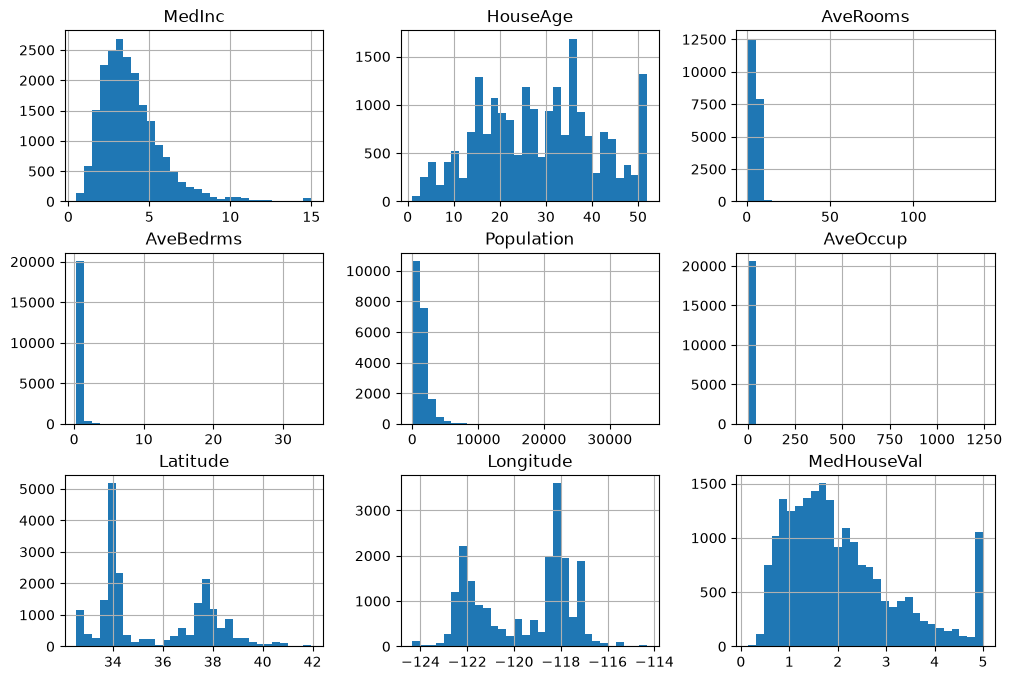

In [5]:
 # Insérez votre code ici pour visualiser la distribution des caractéristiques

import matplotlib.pyplot as plt #imprtation de matplotlib
df.hist(bins=30, figsize=(12,8)) #configuration de l'histogramme
plt.show() #affichage de l'histogramme

> **Questions** :
> - Les distributions sont-elles symétriques ou asymétriques ? Quelles caractéristiques montrent une distribution qui pourrait influencer la performance du modèle ?
> - Quelles caractéristiques contiennent des outliers potentiels ? Comment cela pourrait-il affecter l’entraînement du modèle ?
   

- La plupart sont asymétriques à droite (longue queue vers les grandes valeurs) : AveOccup, AveBedrms, AveRooms, Population, MedInc, MedHouseVal. HouseAge et les coordonnées sont à peu près symétriques.
-  Les outliers sont surtout dans AveOccup, AveRooms, AveBedrms et Population. Ils peuvent tirer une régression linéaire vers eux et fausser les distances.

4. **Analyse de la Corrélation**
   - **Calculez la matrice de corrélation** pour observer les relations linéaires entre les caractéristiques. Utilisez une heatmap pour une visualisation plus claire.
   - Portez une attention particulière à la corrélation entre chaque caractéristique et la cible (`MedHouseVal`) pour identifier les variables potentiellement les plus influentes.

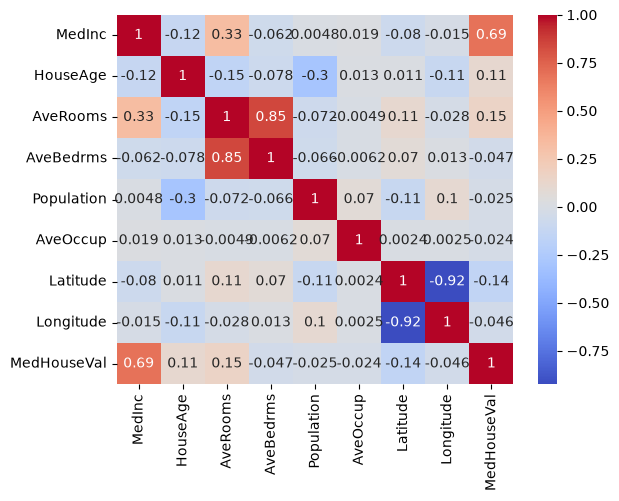

<Figure size 1000x800 with 0 Axes>

In [6]:
# Insérez votre code ici pour calculer et visualiser la matrice de corrélation

df.corr() # calcul de la matrice de corrélation

import seaborn as sns #importation de seaborn 
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') #configuration de la heatmap 
plt.figure(figsize=(10,8)) # configuration de la taille 
plt.show() # affichage de la heatmap

> **Questions** :
> - Quelles caractéristiques semblent fortement corrélées entre elles ? Cela pourrait-il mener à de la redondance dans les données ?
> - Quelles sont les caractéristiques les plus corrélées avec la cible (`MedHouseVal`) ? Pensez-vous que ces caractéristiques auront un impact plus fort sur les prédictions du modèle ?

- Variables fortement corrélées entre elles, redondance ? 
Oui : Latitude/Longitude (−0,92) et AveRooms/AveBedrms (0,85). Elles apportent en partie la même information. C'est de la redondance (on parle de multicolinéarité), qui peut rendre les coefficients d'une régression linéaire instables.
- Variables les plus corrélées avec la cible ? MedInc domine largement. On peut s'attendre à ce qu'elle pèse le plus dans les prédictions.

5. **Relation entre les Caractéristiques et la Cible**
   - **Visualisez la relation** entre la cible (`MedHouseVal`) et quelques caractéristiques pertinentes identifiées lors de l’analyse de corrélation (ex. : revenu médian des ménages, âge médian des maisons).
   - Utilisez des scatter plots ou un `pairplot` pour observer comment la cible varie en fonction des caractéristiques principales.
   - **Explorez la localisation des districts** en fonction de la latitude et de la longitude. Utilisez un scatter plot avec la valeur médiane des logements (`MedHouseVal`) comme code couleur pour visualiser la répartition géographique des valeurs.

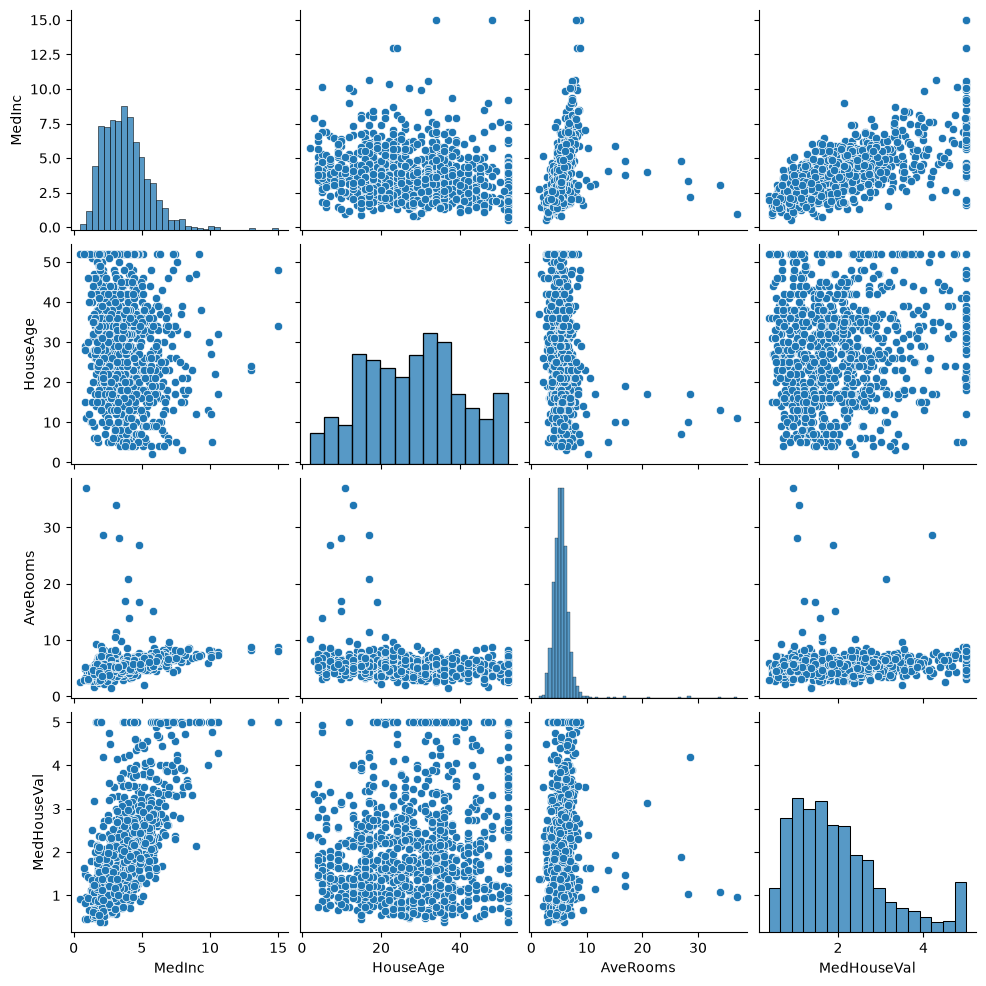

In [7]:
# Insérez votre code ici pour visualiser les relations entre la cible et certaines caractéristiques

#visualisation des relation entre les variables
sns.pairplot(df.sample(1000)[["MedInc", "HouseAge", "AveRooms", "MedHouseVal"]])


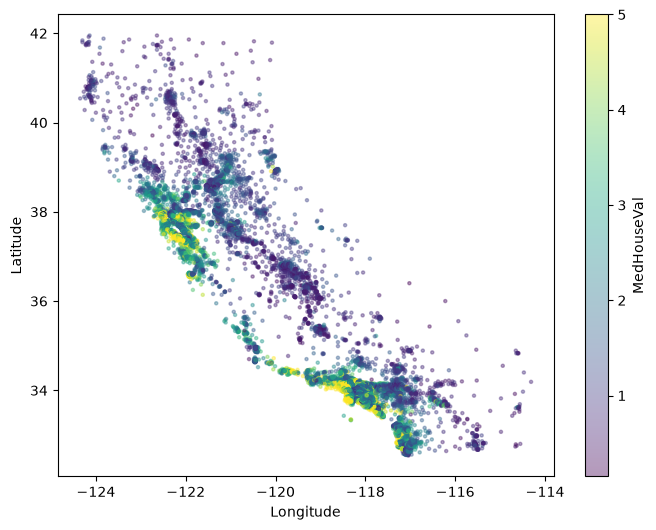

In [8]:
#Carte de la Californie 
plt.figure(figsize=(8, 6))
plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", alpha=0.4, s=5)
plt.colorbar(label="MedHouseVal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

> **Questions** :
> - Les graphiques montrent-ils des relations claires (linéaires, non linéaires) entre certaines caractéristiques et la cible ?
> - En observant ces relations, quelles caractéristiques semblent les plus influentes sur le prix des logements ?
> - **Pour les coordonnées géographiques** : La localisation géographique (latitude et longitude) semble-t-elle avoir un impact sur la valeur des logements ? Observez-vous des zones où les prix sont systématiquement plus élevés ou plus bas ?

- Relations claires entre les caractéristiques et la cible ?

Oui pour MedInc : le prix monte quand le revenu monte, à peu près en ligne droite (relation linéaire), avec de la dispersion et un plafond à 5,0.
Non pour HouseAge : le nuage est en boule, sans direction.
AveRooms est illisible à cause des outliers.
La latitude et la longitude ont un lien non linéaire avec le prix : il dépend de la zone, pas d'une droite.
- Caractéristiques les plus influentes ?

MedInc est la plus influente (corrélation de 0,69).
La localisation (latitude et longitude) compte aussi beaucoup.
HouseAge et AveRooms semblent secondaires.

- Impact de la localisation ?

Oui, l'impact est fort. Les prix les plus élevés sont sur la côte, autour de Los Angeles et de la baie de San Francisco (sur les 1 771 quartiers à plus de 400 000 $, 871 sont autour de Los Angeles et 656 autour de San Francisco).
L'intérieur des terres (vallée centrale) est nettement moins cher, environ 100 000 $ en moyenne contre 207 000 $ pour l'ensemble.


---

## Étape 3 : Prétraitement des Données

**Objectif** : Préparer les données en identifiant et en appliquant les transformations nécessaires pour assurer leur qualité et leur cohérence avant l’entraînement du modèle.

#### Instructions

1. **Vérification et Traitement des Valeurs Manquantes**
   - **Vérifiez s'il y a des valeurs manquantes** dans le dataset, en utilisant des fonctions `pandas` pour détecter les cellules vides.
   - Déterminez ensuite la meilleure approche pour traiter les valeurs manquantes :
     - **Imputation** (recommandée) : Remplir les valeurs manquantes par une statistique appropriée, comme la moyenne ou la médiane, pour éviter la perte d’information.
     - **Suppression** (si nécessaire) : Supprimer les lignes ou colonnes comportant trop de valeurs manquantes.
   - **Note** : Si vous choisissez l’imputation, elle sera effectuée **après la division des données** en ensembles d’entraînement et de test dans l’étape suivante pour éviter la fuite de données (**data leakage**).

In [9]:
# Insérez votre code ici pour vérifier et identifier les valeurs manquantes
# On compte les cases vides dans chaque colonne
print(df.isnull().sum())
# Total de cases vides dans tout le tableau (0 = rien à corriger)
print("Total missing values:", df.isnull().sum().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Total missing values: 0


2. **Encodage des Variables Catégorielles**
   - Si le dataset contient des variables catégorielles, encodez-les en valeurs numériques pour qu'elles soient utilisables par le modèle. Vous pouvez utiliser `OneHotEncoder` ou `LabelEncoder` selon le cas.
   - Vérifiez la nécessité de cette étape en explorant les types de variables dans le dataset.

In [10]:
# Insérez votre code ici pour encoder les variables catégorielles si nécessaire
# On regarde le type de chaque colonne : que des nombres ici
print(df.dtypes)
# On cherche les colonnes de texte (catégories) : il n'y en a aucune, donc pas d'encodage à faire
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", categorical_cols)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
Categorical columns: []


3. **Normalisation ou Standardisation des Données**
   - Les modèles sensibles à l’échelle des données, comme les modèles linéaires ou K-Nearest Neighbors, peuvent nécessiter une **normalisation** (mise à l’échelle de 0 à 1) ou une **standardisation** (centrage à une moyenne de 0 et écart-type de 1).
   > **Note** : La normalisation ou standardisation sera également appliquée **après la division des données** en ensembles d’entraînement et de test, ce qui sera abordé dans l’étape suivante pour éviter toute fuite de données.

---

## Étape 4 : Sélection des Variables, Division des Données et Prétraitement

**Objectif** : Sélectionner les variables pertinentes, séparer les caractéristiques (features) et la cible (target), diviser les données en ensembles d'entraînement et de test, puis appliquer des techniques de prétraitement pour garantir des données prêtes pour l’entraînement.

#### Instructions

1. **Sélection des Variables Pertinentes**
   - **Identifiez les variables** les plus pertinentes pour l’analyse en vous basant sur l’exploration des données (EDA) de l’étape précédente.
   - Choisissez les colonnes à inclure dans les caractéristiques (features) et dans la cible (target) en fonction de leur corrélation ou de leur importance pour la prédiction.


In [11]:
# Insérez votre code ici pour sélectionner les variables pertinentes

# On conserve toutes les variables du dataset (elles sont toutes numériques
# et pertinentes d'après l'EDA), sauf la cible MedHouseVal.
selected_features = df.drop(columns="MedHouseVal").columns.tolist()
print(selected_features)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


2. **Séparation des Caractéristiques (Features) et de la Cible (Target)**
   - **Définissez les features et la target** en créant deux objets séparés, `X` pour les caractéristiques et `y` pour la variable cible.
   - La cible (target) est la variable que l’on souhaite prédire, ici `MedHouseVal` dans le dataset California Housing.

In [12]:
# Insérez votre code ici pour séparer les caractéristiques (X) et la cible (y)

X = df[selected_features]
y = df["MedHouseVal"]

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (20640, 8)
y shape : (20640,)


3. **Division des Données en Ensembles d’Entraînement et de Test**
   - **Divisez les données** en ensembles d’entraînement (`X_train`, `y_train`) et de test (`X_test`, `y_test`) en utilisant `train_test_split`.
   - Cette étape garantit que le modèle est entraîné sur une partie des données (80 %) et évalué sur des données qu’il n’a jamais vues (20 %).
   - **Paramètres recommandés** :
     - `test_size=0.2` : Alloue 20 % des données pour le test et 80 % pour l’entraînement.
     - `random_state=42` : Assure la reproductibilité des résultats.

In [13]:
# Insérez votre code ici pour diviser les données en ensembles d’entraînement et de test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (16512, 8)
X_test shape : (4128, 8)


### 4. Prétraitement des Données : 

#### Syntaxe Générale avec `sklearn.preprocessing`

Le prétraitement des données inclut des étapes comme **l’imputation des valeurs manquantes** et la **mise à l’échelle des données** (normalisation ou standardisation) pour garantir des caractéristiques cohérentes et exploitables par les modèles.

Voici la syntaxe générale pour appliquer les fonctions de prétraitement avec `sklearn.preprocessing` :

```python
# Importer la fonction de prétraitement souhaitée
from sklearn.preprocessing import SomePreprocessingFunction  

# 1. Instancier le préprocesseur
preprocessor = SomePreprocessingFunction()  # Créez une instance de la fonction de prétraitement

# 2. Ajuster et transformer les données d'entraînement
X_train_preprocessed = preprocessor.fit_transform(X_train)  # Apprend les paramètres et applique la transformation sur X_train

# 3. Transformer les données de test
X_test_preprocessed = preprocessor.transform(X_test)  # Utilise les mêmes paramètres pour transformer X_test
```

#### Explication du Code
- **Importer la Fonction de Prétraitement** : Importez la fonction de `sklearn.preprocessing` correspondant à la transformation souhaitée, par exemple `StandardScaler` pour la standardisation ou `SimpleImputer` pour l’imputation.
- **Instancier le Préprocesseur** : Créez une instance de la classe de prétraitement, par exemple `StandardScaler()` ou `SimpleImputer(strategy='mean')`.
- **Ajuster et Transformer les Données d’Entraînement** : Utilisez `.fit_transform()` sur les données d’entraînement pour calculer les paramètres (par exemple, la moyenne et l’écart-type pour la standardisation) et appliquer la transformation en une seule étape.
- **Transformer les Données de Test** : Utilisez `.transform()` sur les données de test pour appliquer la transformation en utilisant uniquement les paramètres appris sur les données d’entraînement.

> **Note** : L’utilisation de `.fit_transform()` sur les données d’entraînement et de `.transform()` uniquement sur les données de test est cruciale pour éviter toute fuite de données (**data leakage**). Cela garantit que les informations de l’ensemble de test restent inconnues pendant l’entraînement du modèle.


#### Applications de Prétraitement

##### 1. **Imputation des Valeurs Manquantes**
   - Utilisez `SimpleImputer` pour combler les valeurs manquantes avec une des trois stratégies :
     - `strategy='mean'` : Remplace par la moyenne.
     - `strategy='median'` : Remplace par la médiane.
     - `strategy='most_frequent'` : Remplace par la valeur la plus fréquente.


In [14]:
# Insérez votre code ici pour imputation des valeurs manquantes des données si nécessaire
# On revérifie qu'il n'y a pas de cases vides après la séparation train / test
# Résultat 0 : pas besoin d'imputation
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


##### 2. **Normalisation ou Standardisation des Données**
   - Pour aligner l’échelle des données, la standardisation ou la normalisation est essentielle, notamment pour les modèles de régression.
   - Utilisez `StandardScaler` pour centrer les données autour de la moyenne et réduire autour de l’écart-type (moyenne 0 et écart-type 1), ou `MinMaxScaler` pour normaliser les valeurs entre 0 et 1.
   - **Instruction** : Utilisez `StandardScaler` pour cette analyse et appliquez-le uniquement sur les données d’entraînement, puis transformez les données de test avec les mêmes paramètres.

> **Note** : Les données standardisées ainsi obtenues seront utilisées pour l’entraînement de vos modèles de régression, garantissant des caractéristiques adaptées aux exigences des algorithmes et prêtes pour le processus d’apprentissage.

In [15]:
# Insérez votre code ici pour préparer la standardisation des données
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)   


---
## Étape 5 : Entraînement des Modèles de Régression


Cette étape vous guide dans l’entraînement de modèles de régression en Machine Learning pour prédire une variable continue, comme dans le cas du California Housing Dataset où la cible est la valeur médiane des maisons.

Chaque modèle que nous allons introduire a des particularités, des forces et des limites en fonction des types de données et des objectifs. Nous aborderons aussi les modèles communs à la classification en montrant comment les utiliser pour la régression.


### Modèles de Régression : Principes et Utilisation en Scikit-Learn


#### Modèle 1 : Régression Linéaire

**Principe** :
La régression linéaire modélise la relation entre une ou plusieurs variables indépendantes et la cible en ajustant un modèle de type ligne droite (ou hyperplan dans le cas de multiples caractéristiques). L’objectif est de minimiser la somme des carrés des erreurs (les résidus) pour obtenir une relation linéaire optimale.

**Utilité** :
Utilisée lorsque la relation entre les caractéristiques et la cible est linéaire. Ce modèle est rapide et interprétable.

**Forces** :
- Simple à interpréter.
- Rapide à entraîner pour les petites et moyennes tailles de données.
- Sensible aux valeurs aberrantes et aux multicolinéarités.

**Limitations** :
- Moins performante pour les relations non linéaires.
- Sensible aux valeurs extrêmes, qui peuvent affecter la précision.

**Prétraitement recommandé** :
Standardisation des données recommandée.

**Classe d’importation** :
```python
from sklearn.linear_model import LinearRegression
```

In [16]:
# Instanciez et entraînez le modèle Régression Linéaire ici

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


#### Modèle 2 : K-Nearest Neighbors (KNN) en Régression

**Principe** :
En régression, KNN utilise la moyenne (ou la médiane) des valeurs cibles des k voisins les plus proches pour faire des prédictions.

**Utilité** :
Particulièrement utile lorsque la cible peut être estimée par la proximité des valeurs similaires dans l’espace des caractéristiques. KNN en régression fonctionne bien pour les petites bases de données, mais il est moins performant sur de grands ensembles de données.

**Forces** :
- Simple à comprendre et à appliquer.
- Performant sur les données locales, sans présupposer une relation linéaire.

**Limitations** :
- Sensible aux dimensions élevées (curse of dimensionality).
- Coût de calcul élevé pour des données volumineuses.

**Prétraitement recommandé** :
Normalisation des données recommandée.

**Classe d’importation** :
```python
from sklearn.neighbors import KNeighborsRegressor
```

In [17]:
# Instanciez et entraînez le modèle KNN ici
from sklearn.neighbors import KNeighborsRegressor
Knn_model = KNeighborsRegressor(n_neighbors=5)
Knn_model.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### Modèle 3 : Régression avec Arbre de Décision (Decision Tree Regressor)

**Principe** :  
En régression, un arbre de décision divise les données en segments en fonction de seuils sur les caractéristiques. Chaque feuille de l’arbre contient une valeur prédite pour la cible, souvent la moyenne des observations présentes dans la feuille.

**Utilité** :  
Idéal pour des données avec des relations non linéaires, où des seuils simples dans les caractéristiques permettent de modéliser les variations de la cible. Il offre aussi une grande transparence, permettant de visualiser la logique derrière les prédictions.

**Forces** :
- Capable de capturer des relations non linéaires entre caractéristiques et cible.
- Peu sensible aux valeurs aberrantes, car il divise simplement les données selon des seuils.

**Limitations** :
- Peut être sujet au surapprentissage (overfitting), en particulier si l’arbre est très profond et que chaque feuille contient peu d’observations.
- Les prédictions manquent de continuité, car elles sont basées sur des moyennes constantes dans chaque feuille.

**Classe d’importation** :
```python
from sklearn.tree import DecisionTreeRegressor
```

In [18]:
# Instanciez et entraînez le modèle Arbre de Décision ici
from sklearn.tree import DecisionTreeRegressor 
model_tree_reg = DecisionTreeRegressor(random_state=42)
model_tree_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

#### Modèle 4 : Forêt d'Arbres Décisionnels en Régression (Random Forest Regressor)

**Principe** :  
La forêt d’arbres en régression construit plusieurs arbres de décision en utilisant des sous-échantillons des données et en réalisant des moyennes des prédictions pour une estimation plus stable. Cette méthode permet de réduire le risque de surapprentissage, car elle agrège des prédictions issues de multiples arbres, chacun entraîné sur un échantillon différent.

**Utilité** :  
Adapté aux données avec des relations complexes ou non linéaires, où un seul arbre pourrait surajuster les données. La forêt moyenne les erreurs de chaque arbre pour obtenir des prédictions plus robustes.

**Forces** :
- Prédictions plus stables grâce à l’agrégation des résultats de plusieurs arbres.
- Capable de capturer des relations complexes et moins sensible aux variations aléatoires dans les données.

**Limitations** :
- Nécessite plus de ressources mémoire et de calcul que les arbres de décision seuls.
- Moins interprétable, car il devient difficile de comprendre la logique des prédictions issues de centaines d’arbres.

**Classe d’importation** :
```python
from sklearn.ensemble import RandomForestRegressor
```

In [19]:
# Instanciez et entraînez le modèle Random Forest ici

from sklearn.ensemble import RandomForestRegressor
model_rforest_reg = RandomForestRegressor(random_state=42)
model_rforest_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Modèle 5 : Support Vector Regression (SVR)

**Principe** : SVR est une extension de la SVM pour la régression. Il cherche à trouver une ligne ou un hyperplan qui maximise la marge dans laquelle les points d’entraînement se trouvent, tout en minimisant les erreurs au-delà de cette marge.

**Utilité** : Utile pour des données complexes où une séparation linéaire n’est pas suffisante. Fonctionne bien avec les données de haute dimension et peut gérer des relations non linéaires.

**Forces** :
- Adapté aux données de haute dimension.
- Peut capturer des relations non linéaires avec des noyaux appropriés (par exemple, RBF).

**Limitations** :
- Coût de calcul élevé pour des grands jeux de données.
- Sensible aux choix des hyperparamètres (`C` et `epsilon`).

**Prétraitement recommandé** : Standardisation des données.

**Paramètres Clés** :
- `C` : Paramètre de régularisation qui contrôle la pénalité pour les erreurs en dehors de la marge.
- `kernel` : Type de noyau utilisé (linéaire, RBF, etc.).
- `epsilon` : Zone de tolérance pour les erreurs, qui définit les points acceptés dans la marge sans pénalité.

**Classe d’importation** :
```python
from sklearn.svm import SVR
```

In [20]:
# Instanciez et entraînez le modèle SVM ici
from sklearn.svm import SVR
model_svr = SVR(kernel='rbf')
model_svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


---
## Étape 6 : Prédiction avec les Modèles

Utilisez les modèles de régression entraînés pour générer des prédictions sur les données de test, puis comparez-les aux valeurs réelles pour évaluer la précision de chaque modèle.

1. **Prédisez les valeurs de la cible** pour chaque modèle en appliquant la méthode `.predict(X_test)`.
2. **Stockez les prédictions** pour chaque modèle afin de faciliter la comparaison.

In [21]:
# Insérez votre code ici pour prédire les classes avec le modèle de Régression Lineaire
y_pred_linear = model.predict(X_test_scaled)

# Insérez votre code ici pour prédire les classes avec le modèle KNN
y_pred_knn = Knn_model.predict(X_test_scaled)

# Insérez votre code ici pour prédire les classes avec le modèle Arbre de Décision
y_pred_tree = model_tree_reg.predict(X_test_scaled)

# Insérez votre code ici pour prédire les classes avec le modèle Random Forest
y_pred_rforest = model_rforest_reg.predict(X_test_scaled)

# Insérez votre code ici pour prédire les classes avec le modèle SVM
y_pred_svr = model_svr.predict(X_test_scaled)

> **Questions** :
> - Comment les valeurs prédites se comparent-elles aux valeurs réelles ? Observez `y_pred` par rapport à `y_test`.
> - Quel modèle semble produire les prédictions les plus précises ?
> - Si vous remarquez des erreurs importantes, quelles caractéristiques ou patterns semblent influencer ces écarts ?

- Comparaison prédit / réel (unité : 100 000 $) : les prédictions suivent globalement les vraies valeurs. Sur les 5 premières observations de test, les valeurs réelles sont 0,48 / 0,46 / 5,0 / 2,19 / 2,78, et la forêt aléatoire prédit 0,51 / 0,73 / 4,94 / 2,51 / 2,27.
- Modèle le plus précis : la forêt aléatoire (Random Forest), confirmé par les métriques de l'étape 8 (R² = 0,80).
- Erreurs importantes : elles se concentrent sur les quartiers dont la cible est plafonnée à 5,0 (184 des 4 128 quartiers de test). Pour la régression linéaire, l'erreur moyenne y est de 1,51 contre 0,49 ailleurs. La régression linéaire prédit aussi des valeurs impossibles : 15 prédictions négatives, et jusqu'à 11,5 alors que le maximum réel est 5,0.

---
## Étape 7 : Interprétation des Modèles de Régression

L’interprétation des modèles de régression vous permet de mieux comprendre les relations entre les caractéristiques et la cible. Dans cette section, vous allez explorer comment chaque modèle interprète les données et quels éléments influencent le plus les prédictions.

#### 1. **Régression Linéaire : Interprétation des Coefficients**

Les **coefficients** de la régression linéaire représentent l’impact de chaque caractéristique sur la cible. Un coefficient positif indique une relation positive, tandis qu’un coefficient négatif montre une relation inverse.

> **Instructions :** Affichez les coefficients et associez-les aux noms des caractéristiques pour voir lesquelles influencent le plus la cible.

MedInc        0.854383
AveBedrms     0.339259
HouseAge      0.122546
Population   -0.002308
AveOccup     -0.040829
AveRooms     -0.294410
Longitude    -0.869842
Latitude     -0.896929
dtype: float64
Intercept: 2.071946937378881


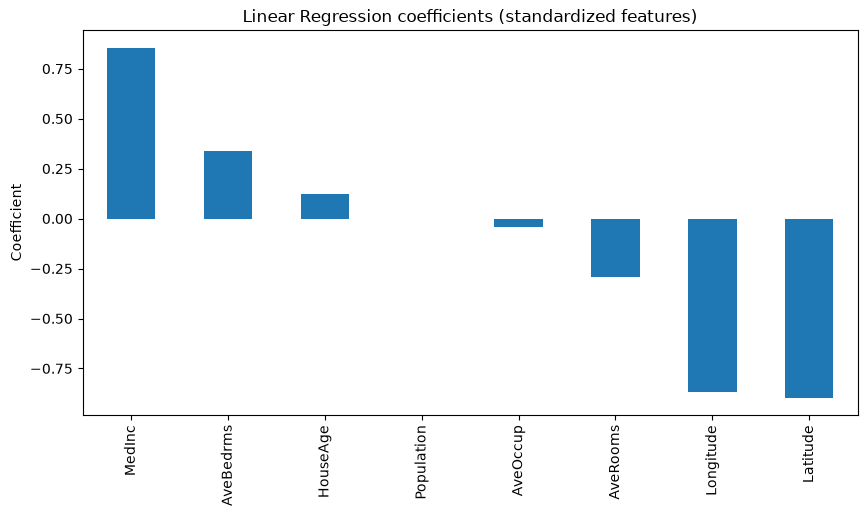

In [22]:
# Insérez votre code ici pour afficher les coefficients de la régression linéaire
# Un coefficient = l'effet d'une variable sur le prix (positif = le prix monte, négatif = il baisse)
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coefficients)
# L'intercept est la valeur de départ du modèle quand toutes les variables sont à 0
print("Intercept:", model.intercept_)

# Graphique en barres pour voir d'un coup d'oeil les variables les plus fortes
coefficients.plot(kind="bar", figsize=(10, 5))
plt.title("Linear Regression coefficients (standardized features)")
plt.ylabel("Coefficient")
plt.show()

> **Questions** :
> - Quels sont les coefficients les plus élevés ?
> - Ces coefficients reflètent-ils vos attentes par rapport aux données ?

- Coefficients les plus élevés : MedInc (+0,85), AveBedrms (+0,34) et HouseAge (+0,12). En valeur absolue, les plus forts sont Latitude (−0,90), Longitude (−0,87) et MedInc (+0,85). Les données ayant été standardisées, les coefficients sont comparables entre eux.
- Attentes : oui pour MedInc (le revenu monte, le prix monte) et pour la localisation (Latitude et Longitude pèsent beaucoup, comme vu dans l'EDA). Moins intuitif : AveRooms est négatif (−0,29) et AveBedrms positif (+0,34). Ces deux variables sont fortement corrélées entre elles (0,85), ce qui rend leurs coefficients instables, comme annoncé à l'étape 2 (multicolinéarité).

#### 2. **K-Nearest Neighbors (KNN) en Régression : Importance des Données Locales**

Le modèle KNN en régression utilise les valeurs des k voisins les plus proches pour faire ses prédictions. L’influence de chaque observation dépend de la proximité dans l’espace des caractéristiques.

> **Instructions :** Choisissez une observation dans `X_test` et identifiez ses k plus proches voisins dans `X_train` pour voir comment leurs valeurs influencent la prédiction.

In [23]:
# Insérez votre code ici pour observer les voisins d'une observation
import numpy as np

# On choisit le premier quartier de X_test
obs_position = 0
# On demande au modèle KNN quels sont ses 5 voisins les plus proches (et à quelle distance)
distances, neighbor_idx = Knn_model.kneighbors(X_test_scaled[[obs_position]])

# On récupère les caractéristiques et le prix réel de ces 5 voisins
neighbors = X_train.iloc[neighbor_idx[0]].copy()
neighbors["distance"] = distances[0]
neighbors["MedHouseVal"] = y_train.iloc[neighbor_idx[0]].values

print("Observation:")
print(X_test.iloc[obs_position])
print()
print("Its 5 nearest neighbors in X_train:")
print(neighbors)
print()
# La prédiction du KNN est simplement la moyenne du prix des 5 voisins
print("Mean of neighbors' target :", neighbors["MedHouseVal"].mean())
print("KNN prediction            :", Knn_model.predict(X_test_scaled[[obs_position]])[0])
print("Real value                :", y_test.iloc[obs_position])

Observation:
MedInc           1.681200
HouseAge        25.000000
AveRooms         4.192201
AveBedrms        1.022284
Population    1392.000000
AveOccup         3.877437
Latitude        36.060000
Longitude     -119.010000
Name: 20046, dtype: float64

Its 5 nearest neighbors in X_train:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20060  1.6469      24.0  4.274194   1.048387      1686.0  4.532258     35.87   
20005  2.0586      28.0  4.509434   1.037736      1434.0  3.865229     36.13   
19842  1.8801      26.0  4.634465   1.086162      1217.0  3.177546     36.42   
20002  1.7432      30.0  4.120448   1.044818      1418.0  3.971989     36.10   
20033  1.5911      29.0  4.570928   1.045534      1659.0  2.905429     36.07   

       Longitude  distance  MedHouseVal  
20060    -119.26  0.323936        0.476  
20005    -119.13  0.347705        0.409  
19842    -119.10  0.361961        0.576  
20002    -119.21  0.415898        0.425  
20033    -119.02  0.439

> **Questions** :
> - Les prédictions du modèle KNN reflètent-elles bien les tendances locales ?
> - Les valeurs des voisins influencent-elles les prédictions comme prévu ?

- Observation étudiée : le premier quartier de X_test (valeur réelle 0,477). Ses 5 voisins ont des valeurs de 0,476 / 0,409 / 0,576 / 0,425 / 0,608, et la prédiction KNN (0,499) est exactement leur moyenne. Elle est proche de la valeur réelle : sur cet exemple, le modèle reflète bien la tendance locale.
- Les voisins ressemblent bien à l'observation (revenu médian entre 1,6 et 2,1, latitude entre 35,9 et 36,4, longitude entre -119,3 et -119,0) et leurs valeurs influencent la prédiction exactement comme prévu : c'est une simple moyenne. Un seul exemple ne suffit pas à conclure pour tout le jeu de données.

#### 3. **Arbre de Décision : Visualisation des Décisions et Importance des Caractéristiques**

Les arbres de décision sont interprétables, car chaque nœud représente une règle de décision. Vous pouvez visualiser l’arbre pour observer comment chaque caractéristique influence la prédiction.

> **Instructions :** Utilisez `plot_tree()` pour visualiser l’arbre et `.feature_importances_` pour voir quelles caractéristiques sont les plus influentes.


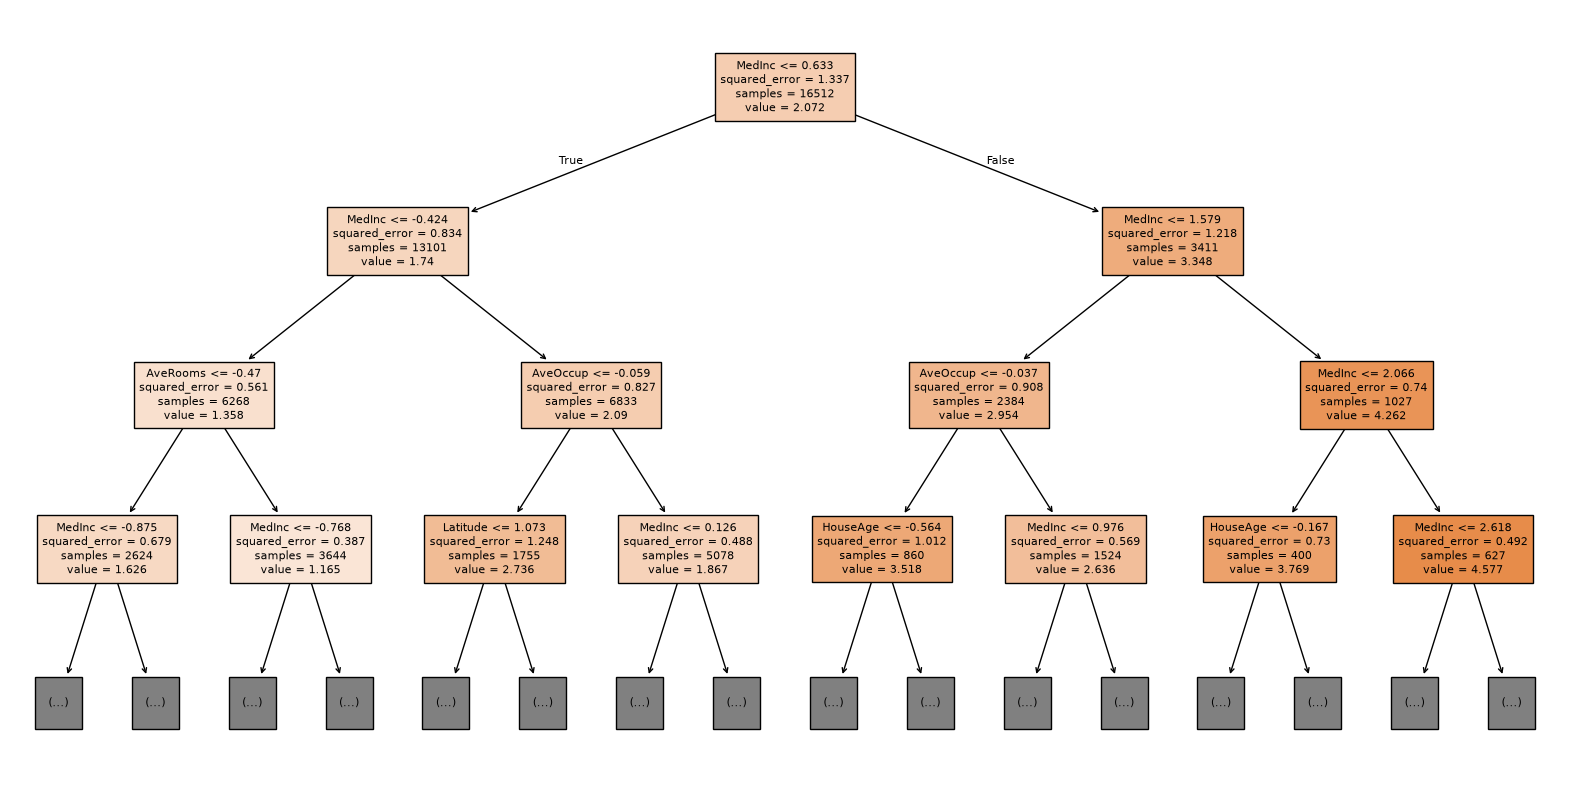

In [24]:
# Insérez votre code ici pour visualiser l'arbre de décision
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    model_tree_reg,
    # On n'affiche que les 3 premiers niveaux, sinon l'arbre complet est illisible
    max_depth=3,
    feature_names=X.columns,
    filled=True,
    fontsize=8,
)
plt.show()

MedInc        0.527758
AveOccup      0.130790
Latitude      0.094034
Longitude     0.083635
AveRooms      0.053534
HouseAge      0.052208
Population    0.030669
AveBedrms     0.027372
dtype: float64


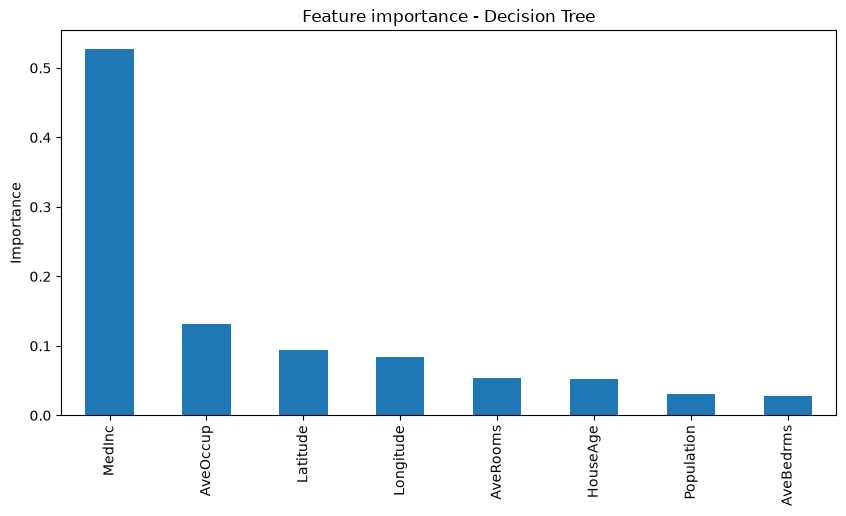

In [25]:
# Insérez votre code ici pour afficher l'importance des caractéristiques
# L'importance dit quelles variables l'arbre utilise le plus pour décider (total = 1)
tree_importances = pd.Series(model_tree_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print(tree_importances)

# Graphique en barres, de la plus importante à la moins importante
tree_importances.plot(kind="bar", figsize=(10, 5))
plt.title("Feature importance - Decision Tree")
plt.ylabel("Importance")
plt.show()

> **Questions** :
> - Les caractéristiques en haut de l’arbre sont-elles les plus influentes ? 
> - Observez-vous des relations intuitives entre les caractéristiques et les décisions de l’arbre ?

- Le premier découpage de l'arbre se fait sur MedInc, et les deux découpages du niveau suivant aussi. MedInc est bien la caractéristique la plus influente (importance 0,53), suivie de AveOccup (0,13), Latitude (0,09) et Longitude (0,08).
- Relation intuitive : l'arbre commence par séparer les quartiers selon le revenu médian, ce qui est cohérent avec la corrélation de 0,69 vue dans l'EDA ; la localisation vient ensuite.
- Remarque : l'arbre complet est énorme (profondeur 34, 15 870 feuilles) et il apprend parfaitement le jeu d'entraînement (R² = 1,0) alors que son R² de test est de 0,62 : c'est du surapprentissage. C'est pourquoi on n'affiche que les 3 premiers niveaux.

#### 4. **Forêt d’Arbres Décisionnels (Random Forest) : Importance des Caractéristiques**

Les forêts d’arbres fournissent une estimation de l'importance des caractéristiques en analysant leur contribution à la réduction de l’erreur. Cette importance est calculée en moyenne sur tous les arbres.

> **Instructions :** Utilisez `.feature_importances_` pour afficher et visualiser l’importance des caractéristiques.


MedInc        0.524955
AveOccup      0.138383
Latitude      0.088879
Longitude     0.088627
HouseAge      0.054664
AveRooms      0.044202
Population    0.030626
AveBedrms     0.029665
dtype: float64


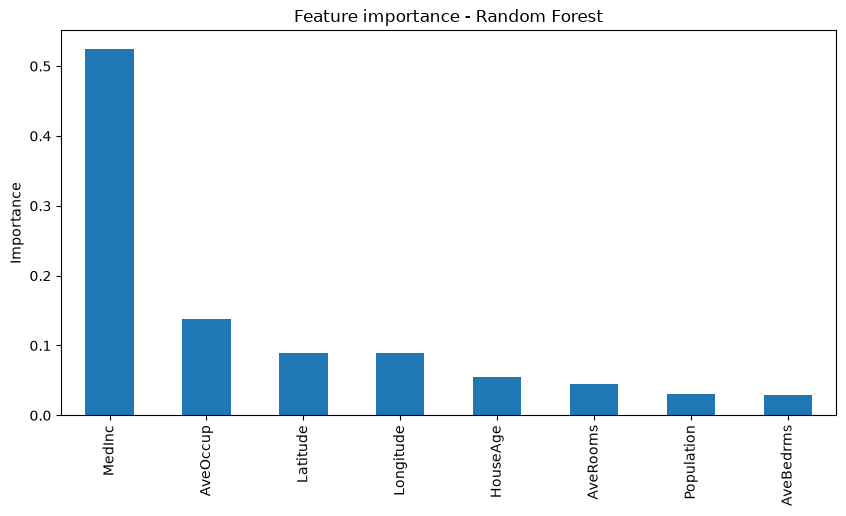

In [26]:
# Insérez votre code ici pour afficher l'importance des caractéristiques dans la Forêt d'Arbres
# Même idée que pour l'arbre, mais moyennée sur tous les arbres de la forêt
rforest_importances = pd.Series(model_rforest_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rforest_importances)

# Graphique en barres, de la plus importante à la moins importante
rforest_importances.plot(kind="bar", figsize=(10, 5))
plt.title("Feature importance - Random Forest")
plt.ylabel("Importance")
plt.show()

> **Questions** :
> - Quelles caractéristiques sont les plus importantes selon le modèle Random Forest ?
> - Ces caractéristiques correspondent-elles aux résultats des autres modèles ?

- Les plus importantes pour la Random Forest : MedInc (0,52), AveOccup (0,14), Latitude (0,09) et Longitude (0,09).
- Correspondance : presque identique à l'arbre de décision (MedInc en tête, puis AveOccup, Latitude, Longitude). Avec la régression linéaire, MedInc et la localisation ressortent aussi, mais AveOccup y compte très peu (coefficient −0,04) : les modèles à base d'arbres captent un effet que le modèle linéaire n'exploite pas.

#### 5. **Support Vector Regression (SVR) : Points de Support et Coefficients**

En SVR, les points de support influencent fortement les prédictions, et dans le cas d’un SVR linéaire, vous pouvez également visualiser les coefficients des caractéristiques. Les points de support sont les observations proches des marges qui contribuent directement à la formation du modèle.

> **Instructions :** Affichez les indices des points de support avec `.support_` et, si vous utilisez un noyau linéaire, accédez aux coefficients avec `.coef_`.

In [27]:
# Points de support du modèle SVR
# Ici le noyau est rbf : on ne peut pas afficher .coef_ (ça ne marche qu'avec un noyau linéaire)
# Nombre de points de support (les observations qui comptent vraiment pour le modèle)
print("Number of support points:", len(model_svr.support_))
# Part de ces points dans les données d'entraînement
print("Share of the training set:", round(len(model_svr.support_) / len(X_train), 3))
# Les positions des 10 premiers points de support
print("First 10 support indices:", model_svr.support_[:10])

Number of support points: 12812
Share of the training set: 0.776
First 10 support indices: [ 0  1  2  4  5  6  7  8  9 10]


> **Questions** :
> - Les points de support représentent-ils des observations particulières ? Sont-ils proches des marges de décision ?
> - Les coefficients reflètent-ils l'influence attendue des caractéristiques ?

- Points de support : 12 812 sur 16 512 observations d'entraînement (78 %). La grande majorité des observations sont donc des points de support : ils ne désignent pas des cas particuliers.
- Coefficients : non disponibles, car le noyau utilisé est `rbf` ; `.coef_` n'existe qu'avec un noyau linéaire. On ne peut donc pas lire directement l'influence des caractéristiques pour ce modèle.

### Résumé et Comparaison des Modèles

Après avoir interprété chaque modèle, comparez leurs caractéristiques influentes.

> **Questions** :
> - Les différents modèles mettent-ils en avant les mêmes caractéristiques comme les plus influentes ?
> - Quel modèle vous semble le mieux aligné avec la structure des données ?
> - En fonction des résultats, quelles caractéristiques ou ajustements pourraient être envisagés pour améliorer les performances ?

- Mêmes caractéristiques ? Largement oui : MedInc est en tête pour la régression linéaire (parmi les plus forts coefficients), l'arbre et la Random Forest, et la localisation (Latitude, Longitude) compte pour les trois. Différence : AveOccup est importante pour l'arbre et la forêt, pas pour la régression linéaire. Le SVR (noyau rbf) ne permet pas cette lecture.
- Modèle le mieux aligné avec la structure des données : la Random Forest, qui a les meilleures métriques (R² = 0,80) et qui gère des relations non linéaires comme celle de la localisation.
- Pistes d'amélioration (non testées dans ce notebook) : tenir compte des valeurs aberrantes (AveRooms, AveOccup, Population) et du plafond de la cible à 5,0 identifiés dans l'EDA, limiter la profondeur de l'arbre pour réduire son surapprentissage, et régulariser la régression linéaire.

---
## Étape 8 : Évaluation des Modèles de Régression

L’évaluation des modèles de régression repose sur des métriques spécifiques qui mesurent la différence entre les valeurs réelles et les valeurs prédites par le modèle. Les principales métriques de régression sont :

#### Métriques d'Évaluation en Régression

1. **Mean Squared Error (MSE) - Erreur Quadratique Moyenne**  
   - **Description** : Mesure la moyenne des carrés des erreurs entre les valeurs réelles et les valeurs prédites. MSE accorde une grande importance aux erreurs importantes en les élevant au carré.
   - **Interprétation** : Plus la MSE est faible, meilleure est la performance du modèle.
   - **Fonction** : `metrics.mean_squared_error(y_test, y_pred)`

In [28]:
# Insérez votre code ici pour calculer la MSE d’un modèle
from sklearn import metrics

# On range les prédictions de chaque modèle dans un dictionnaire pour les comparer facilement
predictions = {
    "Linear Regression": y_pred_linear,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rforest,
    "SVR": y_pred_svr,
}

# MSE = moyenne des erreurs au carré (plus elle est petite, mieux c'est)
mse_scores = {name: metrics.mean_squared_error(y_test, pred) for name, pred in predictions.items()}
for name, value in mse_scores.items():
    print(f"MSE - {name}: {value:.4f}")

MSE - Linear Regression: 0.5559
MSE - KNN: 0.4324
MSE - Decision Tree: 0.5017
MSE - Random Forest: 0.2561
MSE - SVR: 0.3570


> **Questions** :
> - La MSE est-elle particulièrement élevée pour certains modèles ? Pourquoi cela pourrait-il être le cas ?
> - Y a-t-il des modèles avec une MSE particulièrement faible, indiquant une meilleure précision ?

- MSE la plus élevée : régression linéaire (0,556), puis arbre de décision (0,502). La MSE élève les erreurs au carré, donc elle punit les grosses erreurs : la régression linéaire en fait de très grosses (écart maximum de 9,9 sur une observation).
- MSE la plus faible : Random Forest (0,256), puis SVR (0,357) : ce sont les modèles les plus précis selon cette métrique.

2. **Erreur Absolue Moyenne (Mean Absolute Error - MAE)**  
   - **Description** : Calcule la moyenne des valeurs absolues des erreurs entre les prédictions et les valeurs réelles. Contrairement à MSE, MAE ne pénalise pas fortement les grandes erreurs.
   - **Interprétation** : Une MAE plus faible signifie que le modèle fait moins d'erreurs moyennes dans ses prédictions.
   - **Fonction** : `metrics.mean_absolute_error(y_test, y_pred)`

In [29]:
# Insérez votre code ici pour calculer la MAE d’un modèle
# MAE = erreur moyenne en valeur absolue (plus elle est petite, mieux c'est)
mae_scores = {name: metrics.mean_absolute_error(y_test, pred) for name, pred in predictions.items()}
for name, value in mae_scores.items():
    print(f"MAE - {name}: {value:.4f}")

MAE - Linear Regression: 0.5332
MAE - KNN: 0.4462
MAE - Decision Tree: 0.4557
MAE - Random Forest: 0.3278
MAE - SVR: 0.3986


> **Questions** :
> - Comment MAE se compare-t-il entre les modèles ? Un modèle est-il clairement meilleur sur cette métrique ?
> - Y a-t-il des cas où MSE et MAE diffèrent fortement pour un modèle ? Pourquoi cela pourrait-il se produire ?

- MAE : la Random Forest est clairement meilleure (0,328, soit environ 33 000 $ d'erreur moyenne), puis SVR (0,399), KNN (0,446), arbre (0,456) et régression linéaire (0,533, soit environ 53 000 $).
- Écart MSE / MAE : pour la régression linéaire (0,556 vs 0,533) et l'arbre (0,502 vs 0,456), la MSE est plus élevée que la MAE, ce qui indique des erreurs ponctuelles plus grosses que la moyenne. Pour la Random Forest, la MSE (0,256) est bien en dessous de la MAE (0,328) : ses erreurs sont plus régulières.

#### 3. **R² Score (Coefficient de Détermination)**  
   - **Description** : Représente la proportion de la variance de la cible expliquée par le modèle. Il est compris entre 0 et 1 (ou entre -∞ et 1 pour les modèles qui sous-performent).
   - **Interprétation** : Un score proche de 1 signifie que le modèle explique bien les variations de la cible. Un score proche de 0 signifie que le modèle n'explique que peu la variance des données.
   - **Fonction** : `metrics.r2_score(y_test, y_pred)`

In [30]:
# Insérez votre code ici pour calculer le R² Score d’un modèle
# R² = part de la variation du prix expliquée par le modèle (plus il est proche de 1, mieux c'est)
r2_scores = {name: metrics.r2_score(y_test, pred) for name, pred in predictions.items()}
for name, value in r2_scores.items():
    print(f"R2 - {name}: {value:.4f}")

R2 - Linear Regression: 0.5758
R2 - KNN: 0.6700
R2 - Decision Tree: 0.6171
R2 - Random Forest: 0.8045
R2 - SVR: 0.7276


> **Questions** :
> - Quel modèle a le R² le plus élevé ? Ce modèle explique-t-il bien la variance des données ?
> - Y a-t-il des modèles avec des scores R² bas ? Si oui, pourquoi, et qu’est-ce que cela indique sur leurs performances ?

- R² le plus élevé : Random Forest (0,805). Elle explique environ 80 % de la variance du prix, ce qui est bon.
- R² les plus bas : régression linéaire (0,576) et arbre de décision (0,617). La régression linéaire suppose une relation en ligne droite, alors que l'EDA a montré que la localisation agit de façon non linéaire. L'arbre, lui, a un R² de 1,0 sur l'entraînement mais 0,62 sur le test : il a mémorisé les données au lieu de généraliser (surapprentissage).

## Interprétation des Résultats

Une fois les **métriques d’évaluation** calculées pour chaque modèle (MSE, MAE et R² Score), regroupez-les dans un tableau pour une vue d’ensemble. Cela permettra de comparer les performances et d’interpréter les forces et faiblesses de chaque modèle.

#### Instructions pour Regrouper et Analyser les Résultats

1. **Créez un tableau** regroupant les métriques de chaque modèle afin de visualiser leurs performances sur les différentes mesures (MSE, MAE, R²).
2. **Comparez les valeurs** pour déterminer quel modèle est le plus performant selon chaque métrique.
3. **Analysez les écarts entre les métriques** (par exemple, si un modèle a une MSE très différente de son MAE, cela pourrait indiquer des erreurs importantes sur certaines observations).

In [31]:
# Insérez votre code pour organiser les métriques dans un tableau
# Un tableau avec un modèle par ligne et une métrique par colonne
results = pd.DataFrame({
    "MSE": mse_scores,
    "MAE": mae_scores,
    "R2": r2_scores,
}).round(4)
results

,MSE,MAE,R2
Linear Regression,0.5559,0.5332,0.5758
KNN,0.4324,0.4462,0.6700
Decision Tree,0.5017,0.4557,0.6171
Random Forest,0.2561,0.3278,0.8045
SVR,0.3570,0.3986,0.7276


### Interprétation et d’Analyse des Résultats

- **Analyse des performances :**
> - **Quel modèle a la MSE la plus faible ?** Cela indique qu'il a globalement moins d’erreurs de prédiction. Est-ce le cas pour toutes les observations ou uniquement certaines ?
> - **Quel modèle a le MAE le plus faible ?** Cela montre qu’il fait des erreurs moyennes moins importantes. Ce modèle est-il aussi performant en MSE ?
> - **Quel modèle a le R² le plus élevé ?** Un R² proche de 1 indique une forte capacité explicative. Ce modèle est-il également le plus performant en MSE ou MAE ?

- **Comparaison des modèles :**
> - Le modèle ayant la plus faible MSE a-t-il également la plus faible MAE ? Si non, pourquoi ?
> - Le modèle avec le meilleur R² score a-t-il des scores élevés en MSE ou MAE ? 
> - **Sensibilité aux valeurs extrêmes :** Les modèles montrent-ils des variations importantes entre MSE et MAE ? Quels modèles semblent plus sensibles aux valeurs extrêmes ?

### Conclusion des Résultats et Choix du Modèle Optimal

En fonction des résultats, vous serez en mesure de déterminer quel modèle convient le mieux aux données et à la tâche de prédiction.

> **Questions :**
> - **Quel modèle semble le plus adapté en fonction des données et des objectifs ?** Justifiez votre choix.
> - **Compromis entre les métriques :** Quel compromis feriez-vous entre MSE, MAE et R² pour un bon modèle dans ce contexte ?
> - **Implications pratiques :** Au-delà de la performance, quel modèle est le plus pratique et le plus interprétable pour un utilisateur ou un décideur ?

**Analyse des performances**
- MSE, MAE et R² désignent le même meilleur modèle : la Random Forest (MSE 0,256, MAE 0,328, R² 0,805). Ce n'est pas vrai pour toutes les observations : ses erreurs restent plus grandes sur les 184 quartiers plafonnés à 5,0 (erreur moyenne 0,73 contre 0,31 pour les autres).
- Le classement est identique sur les trois métriques : Random Forest, SVR, KNN, arbre de décision, régression linéaire.

**Comparaison des modèles**
- Le modèle avec la plus faible MSE a aussi la plus faible MAE (Random Forest), et il a le meilleur R².
- Sensibilité aux valeurs extrêmes : la régression linéaire et l'arbre ont une MSE supérieure à leur MAE, ce qui signale des erreurs ponctuelles plus grosses ; la Random Forest est la plus régulière.

**Conclusion et choix du modèle**
- Modèle le plus adapté : la Random Forest, car elle est la meilleure sur les trois métriques (erreur moyenne d'environ 33 000 $, R² de 0,80).
- Compromis entre métriques : ici il n'y en a pas à faire, puisque les trois désignent le même modèle. La MAE est la plus facile à expliquer à un client (une erreur moyenne en dollars).
- Implications pratiques : la Random Forest est moins interprétable qu'une régression linéaire ou qu'un arbre unique, dont on peut lire les coefficients ou les règles (étape 7). La régression linéaire est plus simple à expliquer mais explique seulement 58 % de la variance.

---
## Les Challenges de la Régression

L’entraînement de modèles de régression comporte plusieurs défis courants, liés aux caractéristiques des données, aux spécificités des modèles, et aux risques d’ajustement excessif ou insuffisant. Voici les principaux challenges rencontrés en régression et des solutions pour y remédier.


#### 1. **Surapprentissage (Overfitting)**

Le surapprentissage survient lorsque le modèle apprend trop en détail les particularités (y compris le bruit) du jeu de données d’entraînement, ce qui nuit à sa capacité de généralisation sur des données nouvelles.

- **Signes de surapprentissage** :
  - Performances élevées sur le jeu d’entraînement, mais faibles sur le jeu de test (grand écart entre les erreurs de train et de test).
  - R² proche de 1 sur le train, mais beaucoup plus faible sur le test.

- **Solutions pour éviter le surapprentissage** :
  - **Réduire la complexité du modèle** : Limitez la profondeur d’un arbre de décision, diminuez le nombre de voisins pour KNN, ou ajoutez de la régularisation pour la régression linéaire.
  - **Utiliser des techniques de régularisation** : En régression linéaire, appliquez des régularisations L1 (Lasso) ou L2 (Ridge) pour contrôler l’influence des caractéristiques.
  - **Augmenter le volume de données d’entraînement** : Plus de données peuvent aider le modèle à mieux généraliser.

> **Exemple** : Dans une forêt d’arbres décisionnels, un nombre d’arbres trop élevé ou une profondeur importante des arbres peut capturer des variations spécifiques du dataset au lieu de relations générales.


#### 2. **Sous-apprentissage (Underfitting)**

Le sous-apprentissage se produit lorsque le modèle est trop simple pour capturer les relations entre les caractéristiques et la cible. Cela peut conduire à des erreurs de prédiction importantes aussi bien sur le train que sur le test.

- **Signes de sous-apprentissage** :
  - Performances faibles à la fois sur le jeu d’entraînement et le jeu de test.
  - R² faible sur les deux ensembles, indiquant que le modèle n’explique pas bien la variance des données.

- **Solutions pour éviter le sous-apprentissage** :
  - **Augmenter la complexité du modèle** : Utilisez une version plus complexe du modèle (par exemple, un arbre plus profond, un modèle de forêt d’arbres, ou un SVR avec un noyau non linéaire).
  - **Ajouter des caractéristiques pertinentes** : Si des informations importantes sont absentes, intégrer des variables supplémentaires peut aider à mieux prédire la cible.
  - **Essayer un modèle non linéaire** : Les modèles linéaires peuvent sous-apprendre si les données suivent des relations non linéaires.

> **Exemple** : Une régression linéaire appliquée à un dataset avec des relations non linéaires conduira probablement à un sous-apprentissage.


![overfitting-underfitting-regression](../assets/overfitting_underfitting_regression.png)

#### 3. **Données Imparfaites**

Les caractéristiques des données peuvent également poser des défis pour l’entraînement des modèles de régression.

- **Valeurs aberrantes (Outliers)** : Les valeurs extrêmes peuvent fausser les estimations, en particulier pour les modèles sensibles, comme la régression linéaire.
  - **Solution** : Identifiez et traitez les valeurs aberrantes en les supprimant ou en utilisant des modèles moins sensibles aux outliers (ex. : arbres de décision, forêts d’arbres).

- **Données manquantes** : Les valeurs manquantes peuvent créer des biais si elles sont ignorées ou mal imputées.
  - **Solution** : Appliquez une imputation (moyenne, médiane, ou la valeur la plus fréquente) ou envisagez d'utiliser un modèle capable de gérer directement les valeurs manquantes.

> **Exemple** : Dans un modèle de régression linéaire, un outlier extrême peut fausser la pente de la droite de régression et réduire la précision des prédictions.


#### 4. **Multicolinéarité**

La multicolinéarité survient lorsque plusieurs caractéristiques sont fortement corrélées entre elles, rendant difficile pour un modèle linéaire de distinguer leur contribution respective.

- **Impact** : En présence de multicolinéarité, les coefficients des caractéristiques peuvent devenir instables, augmentant la variance et réduisant l’interprétabilité.
- **Solution** : Utilisez une analyse de corrélation pour identifier et éventuellement supprimer les caractéristiques redondantes ou utilisez une régularisation L2 (Ridge) pour réduire la sensibilité du modèle aux corrélations élevées.

> **Exemple** : Dans un dataset immobilier, la surface habitable et le nombre de chambres peuvent être corrélés. Le modèle pourrait avoir du mal à distinguer leur effet individuel sur le prix.



#### 5. **Mauvaise sélection de métriques d’évaluation**

Choisir des métriques inadaptées pour évaluer les modèles de régression peut donner une impression incorrecte de leur performance.

- **Exemples de métriques** :
  - **MSE** met plus l’accent sur les grandes erreurs, ce qui peut être utile dans certains contextes mais trompeur si on veut un aperçu global.
  - **R²** est utile pour voir combien de la variance de la cible est expliquée, mais il peut masquer des erreurs importantes sur des valeurs spécifiques.
  
- **Solution** : Utilisez plusieurs métriques pour avoir une vision complète de la performance du modèle (ex. : MSE, MAE, et R²).



Ces challenges soulignent l’importance de bien choisir les modèles, les transformations de données et les métriques d’évaluation dans les projets de régression. Un bon ajustement des modèles et une compréhension fine des données permettent d’obtenir des résultats fiables et exploitables dans les applications réelles.

---
## Conclusion

Dans ce notebook, nous avons exploré les fondamentaux de la **régression en apprentissage supervisé** et appliqué ces concepts pour modéliser la relation entre les caractéristiques et une variable cible continue, en utilisant le **dataset California Housing** comme cas pratique. Voici les points clés abordés :


1. **Compréhension de l'Apprentissage Supervisé en Régression** :
   - L’apprentissage supervisé repose sur des données étiquetées pour permettre au modèle d’apprendre les relations entre les caractéristiques et la cible. En régression, il s'agit de prédire une valeur continue en fonction des caractéristiques observées.


2. **Exploration et Prétraitement des Données** :
   - Nous avons exploré les caractéristiques du dataset et visualisé les relations entre les caractéristiques et la cible pour mieux comprendre les patterns potentiels dans les données.
   - Les étapes de prétraitement, comme l’imputation des valeurs manquantes et la mise à l’échelle, ont été cruciales pour s’assurer que les données sont prêtes pour l’entraînement du modèle.


3. **Entraînement et Évaluation des Modèles de Régression** :
   - Nous avons entraîné plusieurs modèles de régression, chacun ayant ses avantages et limitations, comme la **régression linéaire**, **l'arbre de décision**, **la forêt aléatoire**, **K-Nearest Neighbors**, et le **SVM (SVR)**.
   - Pour évaluer les performances de chaque modèle, nous avons utilisé des **métriques adaptées à la régression** (MSE, MAE et R²), permettant de quantifier la précision des prédictions sur des données de test.


4. **Challenges et Interprétation des Résultats** :
   - Les défis rencontrés en régression, tels que le surapprentissage, le sous-apprentissage et la multicolinéarité, soulignent l’importance de bien sélectionner les modèles et de comprendre les données.
   - Nous avons interprété les résultats et comparé les modèles pour identifier le modèle le plus adapté aux données et aux objectifs de prédiction.


### Bilan et Application Pratique

À travers ce notebook, vous avez acquis une compréhension complète du **workflow de régression supervisée** : de l'exploration et du prétraitement des données jusqu'à l'entraînement, l'évaluation et l'interprétation des modèles. Ce processus s’applique aux cas réels où la prédiction d’une valeur continue est cruciale, comme l’évaluation immobilière, la prévision des ventes, ou encore l'estimation de la consommation énergétique.

Ces compétences vous offrent une base solide pour aborder d’autres projets de régression en Machine Learning et pour optimiser les modèles en fonction des données disponibles et des objectifs métiers.

---